In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.utils import shuffle

In [2]:
data = pd.read_pickle('data/subset_homework.pckl')
data.get('class_id_1')

[array([[ 27,  25,  25,  25,  20,  21,  29,  36,  38,  27,  42,  57,  62,
          48,  43,  36,  43,  36,  38,  40,  54,  60,  64,  76,  73,  53,
          50,  52],
        [ 33,  30,  24,  19,  22,  22,  23,  32,  30,  35,  38,  39,  48,
          46,  38,  32,  35,  38,  43,  42,  42,  52,  60,  57,  57,  52,
          58,  64],
        [ 47,  34,  29,  24,  20,  21,  21,  24,  33,  29,  34,  44,  45,
          45,  41,  35,  36,  38,  40,  46,  54,  52,  59,  54,  44,  50,
          48,  42],
        [ 43,  39,  37,  27,  23,  26,  23,  25,  31,  33,  36,  44,  59,
          66,  64,  61,  48,  43,  46,  71,  71,  78,  76,  45,  58,  56,
          47,  49],
        [ 40,  39,  48,  42,  27,  26,  27,  25,  40,  56,  88, 106, 112,
         103, 106, 108, 117,  92,  77,  83,  92,  72,  66,  47,  55,  56,
          51,  56],
        [ 46,  42,  50,  60,  48,  26,  27,  43,  73, 107, 110,  83,  87,
          78,  74,  81,  89,  91, 112, 105,  89,  67,  68,  53,  54,  56,
          47

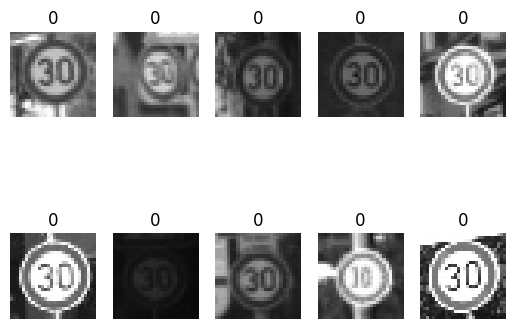

In [3]:
images_0 = data.get('class_id_0')
labels_0 = [0] * len(images_0)

for cnt, idx in enumerate(np.random.randint(0, len(images_0), 10)):
    plt.subplot(2,5,cnt+1)
    plt.imshow(images_0[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels_0[idx]), plt.axis(False)

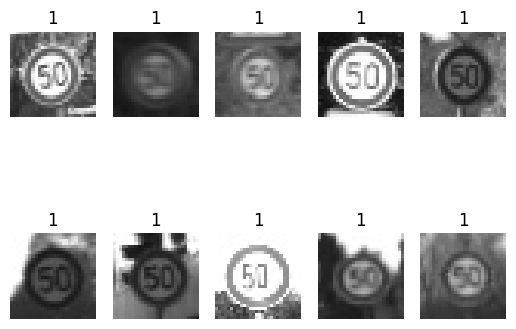

In [4]:
images_1 = data.get('class_id_1')
labels_1 = [1] * len(images_1)

for cnt, idx in enumerate(np.random.randint(0, len(images_1), 10)):
    plt.subplot(2,5,cnt+1)
    plt.imshow(images_1[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels_1[idx]), plt.axis(False)

In [5]:
print(f'Limit 30 - {len(images_0)} images\nLimit 50 - {len(images_1)} images')


Limit 30 - 2220 images
Limit 50 - 2250 images


In [7]:
images = images_0 + images_1
labels = labels_0 + labels_1
images, labels = shuffle(images, labels)

images = np.array(images)
labels = np.array(labels)

In [8]:
pixels = np.array([image.flatten() for image in images])/255

print('Shape', pixels.shape)

Shape (4470, 784)


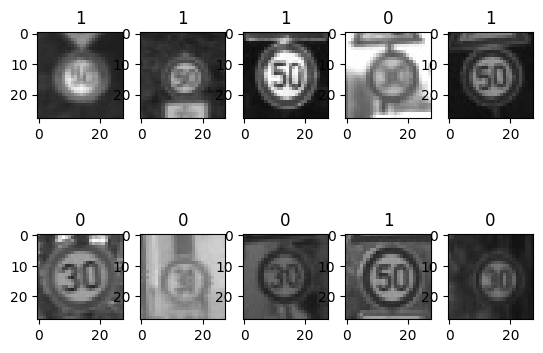

In [9]:
for cnt, idx in enumerate(np.random.randint(0, len(images), 10)):    
    plt.subplot(2,5,cnt+1)
    plt.imshow(images[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(labels[idx]) 
    for cnt, idx in enumerate(np.random.randint(0, len(images), 10)):    
        plt.subplot(2,5,cnt+1)
        plt.imshow(images[idx], cmap='gray', vmin=0, vmax=255)
        plt.title(labels[idx])

In [10]:
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Input

In [11]:
inputs = Input(shape=(pixels.shape[1]))
outputs = Dense(1, activation="linear")(inputs)
model = Model(inputs, outputs)


In [12]:
model.compile(optimizer ='adam', loss = 'mean_squared_error')

In [13]:
trained = model.fit(pixels, labels, epochs=10, batch_size=32)

Epoch 1/10
140/140 [==============================] - 1s 1ms/step - loss: 0.3263
Epoch 2/10
140/140 [==============================] - 0s 1ms/step - loss: 0.2244
Epoch 3/10
140/140 [==============================] - 0s 1ms/step - loss: 0.1831
Epoch 4/10
140/140 [==============================] - 0s 1ms/step - loss: 0.1572
Epoch 5/10
140/140 [==============================] - 0s 1ms/step - loss: 0.1360
Epoch 6/10
140/140 [==============================] - 0s 1ms/step - loss: 0.1263
Epoch 7/10
140/140 [==============================] - 0s 1ms/step - loss: 0.1173
Epoch 8/10
140/140 [==============================] - 0s 2ms/step - loss: 0.1082
Epoch 9/10
140/140 [==============================] - 0s 1ms/step - loss: 0.1040
Epoch 10/10
140/140 [==============================] - 0s 1ms/step - loss: 0.0986


(Text(0.5, 0, 'epoch'), Text(0, 0.5, 'loss'))

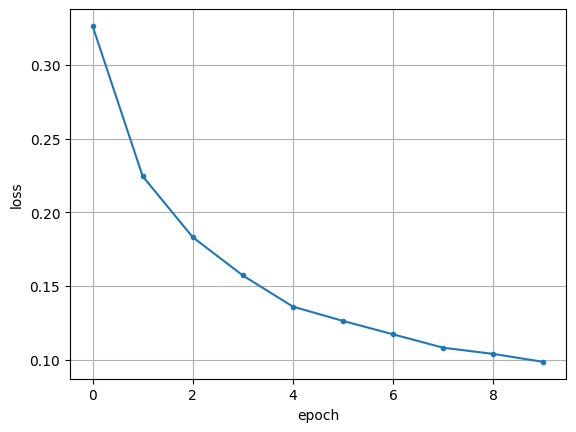

In [14]:
t = trained.history
epochs = range(len(t['loss']))
plt.plot(epochs, t['loss'], '.-'), plt.grid(True)
plt.xlabel('epoch'), plt.ylabel('loss')

[0.40191144] [0.40191144]


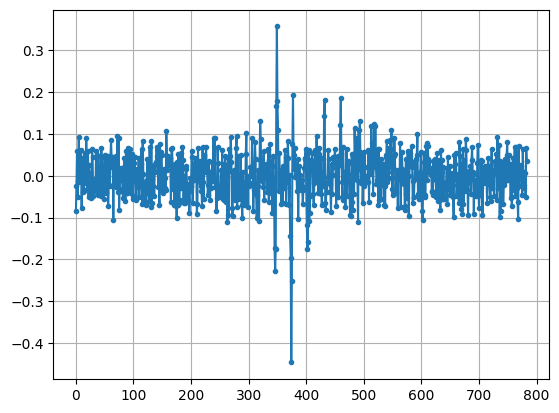

In [15]:
plt.plot(model.layers[1].weights[0].numpy(), '.-'), plt.grid(True)
print(model.layers[1].weights[1].numpy(), model.layers[1].bias.numpy())

In [16]:
idx = 50
preds = model.predict(pixels[idx:idx+1, ...])
print(preds, labels[idx])

1/1 [==============================] - 0s 65ms/step
[[0.49395305]] 1


In [17]:
predictions = model.predict(pixels).squeeze()
predictions = predictions > 0.5

140/140 [==============================] - 0s 1ms/step


In [18]:
correct = 0
for prediction, label in zip(predictions, labels):
    if prediction == label:
        correct = correct + 1

print('Accuracy', correct/len(labels))

Accuracy 0.8829977628635347


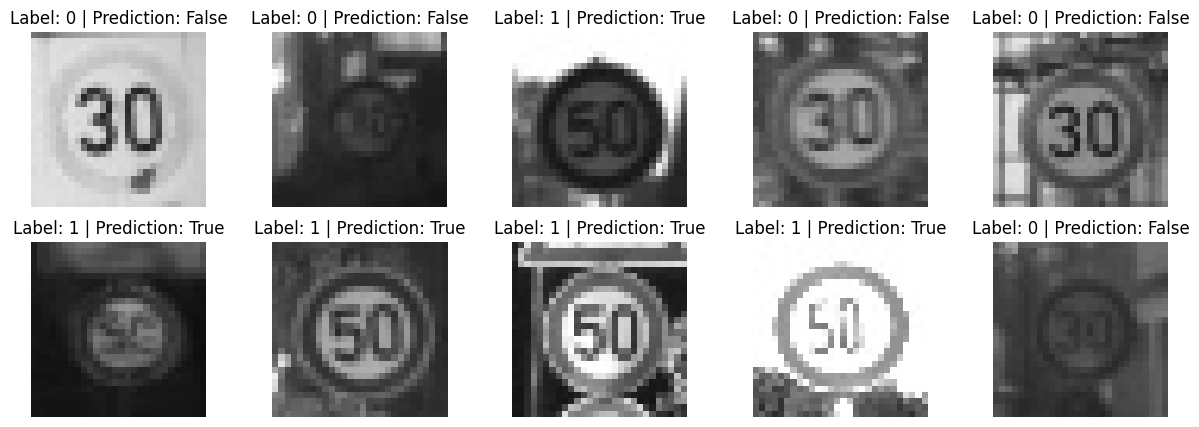

In [19]:
plt.figure(figsize=(15,5))
for cnt, idx in enumerate(np.random.randint(0, len(images), 10)): 
    plt.subplot(2,5,cnt+1), plt.imshow(images[idx], cmap='gray', vmin=0, vmax=255)
    plt.title('Label: ' + str(labels[idx]) + ' | Prediction: ' + str(predictions[idx]))
    plt.axis(False)

In [20]:
inputs = Input(shape=(pixels.shape[1]))
x = Dense(128, activation="relu")(inputs)                  
x = Dense(64, activation="relu")(x)   
x = Dense(32, activation="relu")(x)
outputs = Dense(1, activation="sigmoid")(x)
model = Model(inputs, outputs)
model.compile(optimizer ='adam', loss = 'mean_squared_error')
trained = model.fit(pixels, labels, epochs=20, batch_size=20)

Epoch 1/20
224/224 [==============================] - 1s 2ms/step - loss: 0.2026
Epoch 2/20
224/224 [==============================] - 0s 2ms/step - loss: 0.1117
Epoch 3/20
224/224 [==============================] - 0s 2ms/step - loss: 0.0913
Epoch 4/20
224/224 [==============================] - 0s 2ms/step - loss: 0.0707
Epoch 5/20
224/224 [==============================] - 0s 2ms/step - loss: 0.0563
Epoch 6/20
224/224 [==============================] - 0s 2ms/step - loss: 0.0624
Epoch 7/20
224/224 [==============================] - 0s 2ms/step - loss: 0.0586
Epoch 8/20
224/224 [==============================] - 0s 2ms/step - loss: 0.0644
Epoch 9/20
224/224 [==============================] - 0s 2ms/step - loss: 0.0465
Epoch 10/20
224/224 [==============================] - 0s 2ms/step - loss: 0.0593
Epoch 11/20
224/224 [==============================] - 0s 2ms/step - loss: 0.0514
Epoch 12/20
224/224 [==============================] - 0s 2ms/step - loss: 0.0446
Epoch 13/20
224/224 [====

In [21]:
idx = 50
preds = model.predict(pixels[idx:idx+1, ...])
predictions = model.predict(pixels).squeeze()
predictions = predictions > 0.5
correct = 0
for prediction, label in zip(predictions, labels):
    if prediction == label:
        correct = correct + 1

print('Accuracy', correct/len(labels))

140/140 [==============================] - 0s 1ms/step
Accuracy 0.9570469798657718


##### So, I added a few hidden layers with more neurons and increase amount of epochs, change activetion function to relu for hidden layers and sigmoid for output while fitting and this allows to increase accuracy by 0.04, but we can say that the base 1 neuron model performs well.